In [ ]:
"""
Author    : Mohammad Norizadeh Cherloo
Project   : MNIST Digit Classification
Algorithm : PlainNet – PyTorch
"""
import torch
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader,Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.datasets import load_digits
from torch.nn import functional as F
import torchvision
from torchvision.transforms import ToTensor, Lambda
from torch import nn, optim

In [11]:
from torch.utils.data import DataLoader, random_split

# %% MNIST dataset
num_classes = 10
batch_size = 32

# target_transform = Lambda(
#     lambda y: torch.zeros(num_classes).scatter_(0, torch.tensor(y), 1)
# )

full_train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=ToTensor(),
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=ToTensor(),
)


In [12]:
train_size = 50000
val_size   = 10000

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)


In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [14]:
class LightPlainNet(nn.Module):
    def __init__(self,num_classes= 10):
        super(LightPlainNet, self).__init__()
        # ******************* stem ********************#
        self.stem= nn.Sequential(nn.Conv2d(in_channels=1,out_channels=16,
                                           kernel_size=5,padding=2,stride=1),
                                 nn.BatchNorm2d(16),
                                 nn.ReLU(),
                                 nn.MaxPool2d(kernel_size=2,stride=2))
        # ******************* body ********************#
        self.pln1= Plain(16,16)
        self.pln2= Plain(16,16)
        self.pln3= Plain(16,16)
        
        self.pln4= Plain(16,32)
        self.pln5= Plain(32,32)
        self.pln6= Plain(32,32)
        
        self.pln7= Plain(32,64,s=2)
        self.pln8= Plain(64,64)
        self.pln9= Plain(64,64)
        
        self.pln10= Plain(64,128,s=2)
        self.pln11= Plain(128,128)
        self.pln12= Plain(128,128)

        # ******************* head ********************#
        self.head= nn.Sequential(nn.AdaptiveAvgPool2d((2,2)),
                                 nn.Flatten(),
                                #  nn.Dropout(0.4),
                                 nn.LazyLinear(num_classes))
    def forward(self,x):
       # X: bs x 1 x H x W
       out= self.stem(x)
       out= self.pln1(out)
       out= self.pln2(out)
       out= self.pln3(out)
       
       out= self.pln4(out)
       out= self.pln5(out)
       out= self.pln6(out)
       
       out= self.pln7(out)
       out= self.pln8(out)
       out= self.pln9(out)
       
       out= self.pln10(out)
       out= self.pln11(out)
       out= self.pln12(out)
       
       out= self.head(out)
       return out

class Plain(nn.Module):
    def __init__(self,in_chns,out_chns,s=1):
        super(Plain, self).__init__()
        self.plain_b= nn.Sequential(nn.Conv2d(in_channels=in_chns,out_channels=out_chns,
                                            kernel_size= 3,padding=1,stride=s),
                                  nn.BatchNorm2d(out_chns),
                                  nn.ReLU(),
                                  
                                  nn.Conv2d(in_channels=out_chns,out_channels=out_chns,
                                            kernel_size= 3,padding=1),
                                  nn.BatchNorm2d(out_chns),
                                  nn.ReLU()) 
    def forward(self,x):
        out= self.plain_b(x)# H(x)
        return out 

In [15]:
model= LightPlainNet(num_classes= 10)
n_out=10

criterion= nn.CrossEntropyLoss()
optimizer= optim.Adam(params=model.parameters(),
                      lr=0.001)

In [ ]:
mse=[]
epoch=2
for iter in range(epoch):
     er=[]
     for i,(xbatch,ybatch) in enumerate(train_loader):
          model.train()
          # farward pass
          ypred= model(xbatch)
          optimizer.zero_grad()
          loss= criterion(ypred,ybatch.long())
          loss.backward()
          optimizer.step()

          er.append(loss.detach()) 
          if i%500==0:
               model.eval()
               loss= torch.mean(torch.tensor(er))
               mse.append(loss)
               # validation
               with torch.no_grad():
                    y_pred=[]
                    y_true=[]
                    for j,(xbatch,ybatch) in enumerate(val_loader):
                         # farward pass
                         ypred= model(xbatch)
                         ypred= torch.argmax(ypred,dim=1)
                         y_pred.extend(ypred.numpy())
                         y_true.extend(ybatch.numpy())
                         
                    y_pred= np.array(y_pred)
                    y_true= np.array(y_true)
                    accuracy= np.sum(y_true==y_pred)/y_pred.shape[0]*100
                    print(f'MSE({iter}:{i}): {loss:.6f} **** Acc:{accuracy:.3f}%')
               model.train()
mse=torch.tensor(mse)

plt.subplot(2,1,1)
plt.plot(mse)
plt.show()

MSE(0:0): 2.282704 **** Acc:11.520%
MSE(0:5): 2.403227 **** Acc:11.520%
MSE(0:10): 2.370501 **** Acc:11.520%
MSE(0:15): 2.322178 **** Acc:11.520%
MSE(0:20): 2.272581 **** Acc:11.520%
MSE(0:25): 2.233905 **** Acc:11.520%
MSE(0:30): 2.161482 **** Acc:11.520%
MSE(0:35): 2.080306 **** Acc:11.520%
MSE(0:40): 2.014104 **** Acc:12.010%
MSE(0:45): 1.970214 **** Acc:20.050%
MSE(0:50): 1.908638 **** Acc:14.750%
MSE(0:55): 1.843760 **** Acc:49.340%
MSE(0:60): 1.799173 **** Acc:53.990%
MSE(0:65): 1.745613 **** Acc:40.600%
MSE(0:70): 1.705656 **** Acc:55.170%
MSE(0:75): 1.654843 **** Acc:63.520%
MSE(0:80): 1.613100 **** Acc:64.060%
MSE(0:85): 1.571343 **** Acc:61.620%
MSE(0:90): 1.536282 **** Acc:62.920%
MSE(0:95): 1.496022 **** Acc:59.870%
MSE(0:100): 1.459344 **** Acc:67.660%
MSE(0:105): 1.421876 **** Acc:58.690%
MSE(0:110): 1.385286 **** Acc:61.310%
MSE(0:115): 1.353365 **** Acc:74.670%
MSE(0:120): 1.321187 **** Acc:81.620%
MSE(0:125): 1.292306 **** Acc:75.370%
MSE(0:130): 1.269994 **** Acc:62.9

KeyboardInterrupt: 

C:\Users\Cherloo\AppData\Local\Temp\ipykernel_19620\1161428258.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mse=torch.tensor(mse)


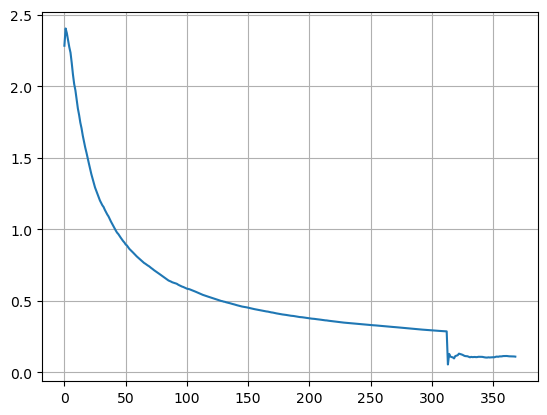

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(mse)
plt.grid()
plt.show()

Total accuracy:97.760%
accuracy0:99.592%
accuracy1:98.767%
accuracy2:97.578%
accuracy3:98.020%
accuracy4:99.491%
accuracy5:97.646%
accuracy6:95.094%
accuracy7:98.346%
accuracy8:96.099%
accuracy9:96.729%


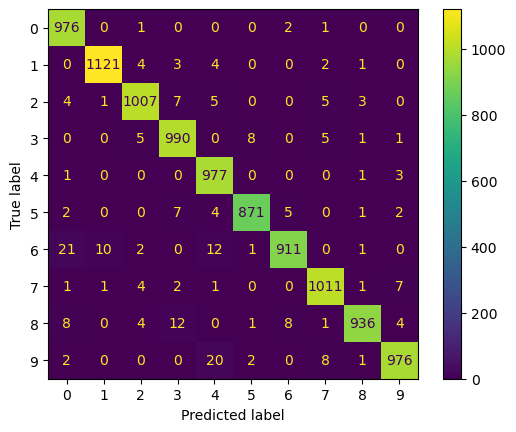

In [18]:
# validation
y_pred=[]
y_true=[]
model.eval()
with torch.no_grad():
    for i,(xbatch,ybatch) in enumerate(test_loader):
        # farward pass
        ypred= model(xbatch)
        ypred= torch.argmax(ypred,dim=1)
        y_pred.extend(ypred.numpy())
        y_true.extend(ybatch.numpy())
        
    y_pred= np.array(y_pred)
    y_true= np.array(y_true)

    from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
    #%% test trained Neural Network
    C= confusion_matrix(y_true,y_pred)
    # print(C)
    accuracy= np.sum(np.diag(C))/ np.sum(C) *100
    print(f'Total accuracy:{accuracy:.3f}%')

for i in range(n_out):
    accuracyi= C[i,i]/ np.sum(C[i,:]) *100
    print(f'accuracy{i}:{accuracyi:.3f}%')
# plt.figure()
disp= ConfusionMatrixDisplay(C)
disp.plot()
plt.show()